In [3]:
import json
from pathlib import Path

notebook_path = Path("Code.ipynb")

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

imports = set()

for cell in nb["cells"]:
    if cell["cell_type"] == "code":
        for line in cell["source"]:
            if line.strip().startswith("import") or line.strip().startswith("from"):
                imports.add(line.strip())

for imp in sorted(imports):
    print(imp)


from IPython.display import HTML
from IPython.display import HTML, display
from IPython.display import display
from collections import defaultdict
from convokit import Corpus, download
from gensim import corpora
from gensim.models import LdaModel
from gensim.models import LdaModel, CoherenceModel
from gensim.models import Phrases
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.phrases import Phraser
from pathlib import Path
from scipy.optimize import linear_sum_assignment
from tqdm import tqdm
import contractions
import convokit
import gensim
import html
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas as pd, numpy as np, scipy, gensim, spacy, contractions, matplotlib, seaborn, tqdm, sys
import random
import re
import scipy
import seaborn as sns
import spacy
import sys
imports = set()
imports.add(line.strip())


In [15]:
%%capture

%pip install gensim contractions convokit seaborn

In [16]:
import pandas as pd
import numpy as np
import scipy, gensim, spacy, contractions, matplotlib, seaborn, tqdm, sys
import convokit

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("gensim:", gensim.__version__)
print("spacy:", spacy.__version__)
 
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)
print("tqdm:", tqdm.__version__)
 
print("python:", sys.version)


pandas: 3.0.3
numpy: 2.4.6
scipy: 1.17.1
gensim: 4.4.0
spacy: 3.8.14
matplotlib: 3.10.9
seaborn: 0.13.2
tqdm: 4.67.3
python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [20]:
%pip show contractions

Name: contractions
Version: 0.1.73
Summary: Fixes contractions such as `you're` to you `are`
Home-page: https://github.com/kootenpv/contractions
Author: Pascal van Kooten
Author-email: kootenpv@gmail.com
License: MIT
Location: c:\Users\frank\AppData\Local\Programs\Python\Python312\Lib\site-packages
Requires: textsearch
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%%capture

from convokit import Corpus, download

corpus = Corpus(filename=download("conversations-gone-awry-cmv-corpus"))


In [31]:
corpus.print_summary_stats()
 

Number of Speakers: 9548
Number of Utterances: 42964
Number of Conversations: 6842


In [6]:
import pandas as pd
from tqdm import tqdm
import spacy
import html
import re
import contractions
from gensim.models import Phrases
from gensim.models.phrases import Phraser
from gensim import corpora

# extract conversations 
conversation_ids = []
original_texts = []

for convo in tqdm(corpus.iter_conversations(), desc="Extracting conversations"):
    convo_id = convo.id
    text = " ".join(utt.text.strip() for utt in convo.iter_utterances() if utt.text)
    conversation_ids.append(convo_id)
    original_texts.append(text)

df_corpus = pd.DataFrame({
    "conversation_id": conversation_ids,
    "original_text": original_texts
})

# clean text (remove HTML, contractions, etc.)
tqdm.pandas(desc="Cleaning text")

# load spaCy model and stopwords
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
stopwords = nlp.Defaults.stop_words

# add custom stopwords
custom_stopwords = {
    # Reddit artifacts
    "gt", "amp", "nbsp", "quote", "edit", "edit2", "edit3", "post", "comment",
    # discourse markers
    "iirc", "imo", "imho", "eh", "yeah", "uh", "oh", "lol", "ta", "ok", "okay", 
    "thanks", "thank", "please", "sure", "alright",
    # politeness and hedges
    "well", "maybe", "perhaps", "honestly", "basically", "probably", "really", "seems",
    # high-frequency verbs
    "think", "like", "know", "want", "feel", "mean", "try", "look", "come", "use",
    "need", "believe", "actually", "make", "get", "say", "see", "take", "tell", "give", 
    "put", "go", "talk", "keep", "hear", "read",
    # adjectives/adverbs
    "right", "wrong", "true", "false", "good", "bad", "great", "big", "small",
    "real", "literally", "totally", "yes", "no",
    # reddit short forms and tokens
    "d", "r", "op", "m", "s", "t", "nt", "ve", "ll", "re", "-", "--", "---",
    # generic content words
    "thing", "point", "example", "lot", "agree", "view", "case", "let", "far", "base",
    "understand", "support", "consider", "allow", "ask", "stop", "help", "kind", "simply",
    "start", "opinion", "assume", "act", "end", "action", "term", "sense", "hard", "day"
}
stopwords |= custom_stopwords

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = contractions.fix(text)                # expand contractions
    text = html.unescape(text)                   # decode HTML entities
    text = re.sub(r'(^|\n)>[^\n]*', '', text)    # remove ALL markdown-style quote lines
    text = re.sub(r'\[deleted\]|\[removed\]', '', text)  # remove deleted/removed placeholders
    text = re.sub(r'\n+', ' ', text)             # collapse multiple newlines into space
    text = re.sub(r'\s+', ' ', text).strip()     # normalize whitespace
    return text

df_corpus["clean_text"] = df_corpus["original_text"].progress_apply(clean_text)

# tokenization and lemmatization
def preprocess(text):
    doc = nlp(text.lower())
    return [
        "trans" if token.lemma_.lower() == "tran" else token.lemma_.lower()
        for token in doc
        if (token.is_alpha or '-' in token.text)
        and token.lemma_.lower() not in stopwords
    ]

df_corpus["tokens"] = df_corpus["clean_text"].progress_apply(preprocess)

# apply bigrams and trigrams
tokenized_docs = df_corpus["tokens"].tolist()

bigram = Phrases(tokenized_docs, min_count=5, threshold=10)
trigram = Phrases(bigram[tokenized_docs], min_count=5, threshold=10)

bigram_phraser = Phraser(bigram)
trigram_phraser = Phraser(trigram)

df_corpus["tokens_bigram"] = df_corpus["tokens"].apply(lambda x: bigram_phraser[x])
df_corpus["tokens_trigram"] = df_corpus["tokens_bigram"].apply(lambda x: trigram_phraser[x])

# create dictionary and corpus
texts_for_lda = df_corpus["tokens_trigram"].tolist()

dictionary = corpora.Dictionary(texts_for_lda)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus_bow = [dictionary.doc2bow(text) for text in texts_for_lda]

# assign document numbers
df_corpus = df_corpus.reset_index(drop=True)
df_corpus["doc_num"] = df_corpus.index + 1  # Start at 1 if preferred

 

Extracting conversations: 6842it [00:00, 26392.15it/s]
Cleaning text: 100%|██████████| 6842/6842 [08:46<00:00, 13.00it/s]


In [7]:
import html
df_corpus["original_unescaped"] = df_corpus["original_text"].apply(html.unescape)


In [106]:
df_corpus.to_csv("cga_cmv_preprocessed_final.csv", index=False, encoding="utf-8", columns=[
    "doc_num",
    "conversation_id",
    "original_text",
    "original_unescaped",  # for use in RTA
    "clean_text",
    "tokens_trigram"        
])


In [109]:
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt
import numpy as np

k_values = list(range(5, 45, 5))  # try K = 5, 10, ..., 40
coherence_scores = []

for k in tqdm(k_values, desc="Running LDA for different K"):
    lda_model = LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        chunksize=2000,
        passes=10,
        iterations=100,
        alpha='symmetric',
        eta='symmetric',
        eval_every=None   
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=df_corpus["tokens_trigram"],   
        dictionary=dictionary,
        coherence='c_npmi',
        window_size=20
    )

    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)


Running LDA for different K:   0%|          | 0/8 [00:00<?, ?it/s]

Running LDA for different K: 100%|██████████| 8/8 [13:20<00:00, 100.12s/it]


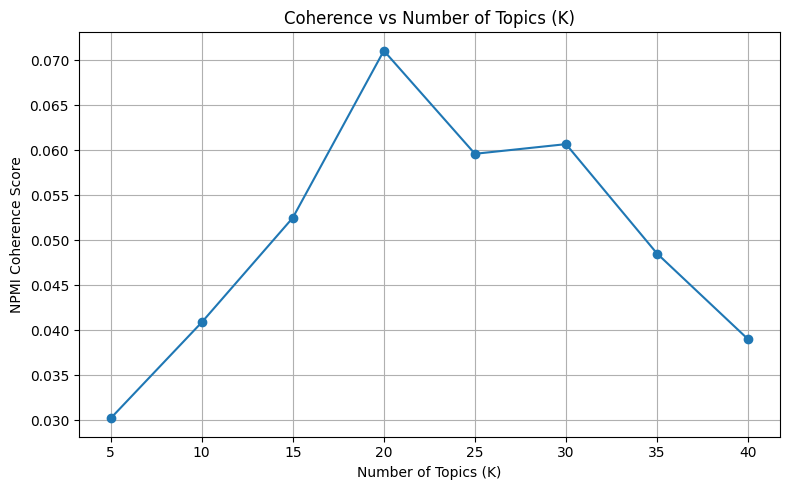

In [110]:

plt.figure(figsize=(8, 5))
plt.plot(k_values, coherence_scores, marker='o')
plt.title("Coherence vs Number of Topics (K)")
plt.xlabel("Number of Topics (K)")
plt.ylabel("NPMI Coherence Score")
plt.grid(True)
plt.xticks(k_values)
plt.tight_layout()
plt.show()


In [111]:
# Print summary table
print("\nSummary of Coherence Scores:")
for k, score in zip(k_values, coherence_scores):
    print(f"K={k:<2} | NPMI Coherence = {score:.4f}")



Summary of Coherence Scores:
K=5  | NPMI Coherence = 0.0302
K=10 | NPMI Coherence = 0.0409
K=15 | NPMI Coherence = 0.0525
K=20 | NPMI Coherence = 0.0711
K=25 | NPMI Coherence = 0.0596
K=30 | NPMI Coherence = 0.0607
K=35 | NPMI Coherence = 0.0485
K=40 | NPMI Coherence = 0.0390


In [ ]:
k_values = list(range(16,25))   
coherence_scores = []

for k in tqdm(k_values, desc="Running LDA for different K"):
    lda_model = LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        chunksize=2000,
        passes=10,
        iterations=100,
        alpha='symmetric',
        eta='symmetric',
        eval_every=None   
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=df_corpus["tokens_trigram"],   
        dictionary=dictionary,
        coherence='c_npmi',
        window_size=20
    )

    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)

Running LDA for different K: 100%|██████████| 9/9 [14:13<00:00, 94.79s/it]


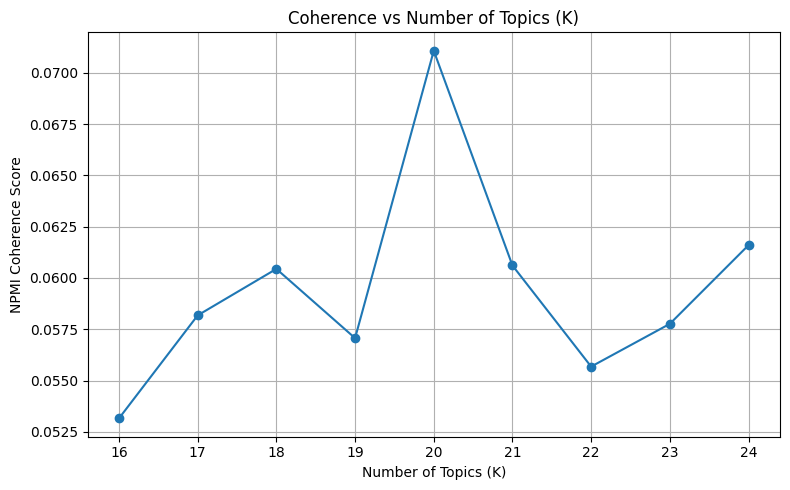

In [113]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, coherence_scores, marker='o')
plt.title("Coherence vs Number of Topics (K)")
plt.xlabel("Number of Topics (K)")
plt.ylabel("NPMI Coherence Score")
plt.grid(True)
plt.xticks(k_values)
plt.tight_layout()
plt.show()


In [114]:
# Print summary table
print("\nSummary of Coherence Scores:")
for k, score in zip(k_values, coherence_scores):
    print(f"K={k:<2} | NPMI Coherence = {score:.4f}")


Summary of Coherence Scores:
K=16 | NPMI Coherence = 0.0532
K=17 | NPMI Coherence = 0.0582
K=18 | NPMI Coherence = 0.0604
K=19 | NPMI Coherence = 0.0571
K=20 | NPMI Coherence = 0.0711
K=21 | NPMI Coherence = 0.0606
K=22 | NPMI Coherence = 0.0557
K=23 | NPMI Coherence = 0.0578
K=24 | NPMI Coherence = 0.0616


In [13]:
import random
random.seed(48)
print([random.randint(1, 1000) for _ in range(5)])


[562, 324, 136, 571, 729]


In [118]:
from gensim.models import LdaModel, CoherenceModel
from scipy.optimize import linear_sum_assignment
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Settings ===
SEEDS = [562, 324, 136, 571, 729]
TOP_N = 10
K = 20  # Replace with your best K
texts_for_lda = df_corpus["tokens_trigram"]

# === Containers ===
top_words_runs = []
coherence_scores = []
duplicate_counts = []
intra_run_overlap_scores = []

# === Fit LDA Models and Collect Metrics ===
for seed in tqdm(SEEDS, desc="Fitting LDA + Coherence + Overlap"):
    lda_model = LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=K,
        random_state=seed,
        iterations=100,
        passes=10,
        alpha='symmetric',
        eta='symmetric',
        eval_every=None
    )

    # extract top-N words per topic
    top_words = []
    for topic_id in range(K):
        words = [word for word, _ in lda_model.show_topic(topic_id, topn=TOP_N)]
        top_words.append(set(words))
    top_words_runs.append(top_words)

    # compute NPMI coherence
    cm = CoherenceModel(
        model=lda_model,
        texts=texts_for_lda,
        dictionary=dictionary,
        coherence='c_npmi'
    )
    coherence = cm.get_coherence()
    coherence_scores.append(coherence)

    # count duplicate topics within a run (Jaccard ≥ 0.30)
    duplicates = 0
    for i in range(K):
        for j in range(i + 1, K):
            inter = len(top_words[i].intersection(top_words[j]))
            union = len(top_words[i].union(top_words[j]))
            jaccard = inter / union
            if jaccard >= 0.30:
                duplicates += 1
    duplicate_counts.append(duplicates)

    # compute average intra-run topic overlap (Jaccard across all topic pairs)
    intra_jaccards = []
    for i in range(K):
        for j in range(i + 1, K):
            inter = len(top_words[i].intersection(top_words[j]))
            union = len(top_words[i].union(top_words[j]))
            jaccard = inter / union
            intra_jaccards.append(jaccard)
    avg_intra_run_overlap = np.mean(intra_jaccards)
    intra_run_overlap_scores.append(avg_intra_run_overlap)

# === Cross-run Topic Alignment (Hungarian Matching) ===
alignment_scores = []

for i in tqdm(range(len(SEEDS)), desc="Cross-run alignment"):
    for j in range(i + 1, len(SEEDS)):
        matrix = np.zeros((K, K))
        for a in range(K):
            for b in range(K):
                inter = len(top_words_runs[i][a].intersection(top_words_runs[j][b]))
                union = len(top_words_runs[i][a].union(top_words_runs[j][b]))
                matrix[a, b] = inter / union
        row_ind, col_ind = linear_sum_assignment(-matrix)
        matched_scores = matrix[row_ind, col_ind]
        alignment_scores.append(matched_scores.mean())

alignment_mean = np.mean(alignment_scores)
alignment_std = np.std(alignment_scores)
intra_run_mean = np.mean(intra_run_overlap_scores)
intra_run_std = np.std(intra_run_overlap_scores)
coherence_mean = np.mean(coherence_scores)
coherence_std = np.std(coherence_scores)

# === Results Table ===
results_df = pd.DataFrame({
    "Seed": SEEDS,
    "Coherence (NPMI)": [f"{c:.4f}" for c in coherence_scores],
    "Max Duplicate Topics": [f"{d} / {K}" for d in duplicate_counts],
    "Avg. Intra-run Overlap": [f"{x:.4f}" for x in intra_run_overlap_scores]
})

print("\n=== Per-Seed Results ===")
print(results_df.to_string(index=False))

# === Summary Metrics ===
print(f"\nAvg. cross-run topic alignment (Jaccard on top-{TOP_N}): {alignment_mean:.4f} ± {alignment_std:.4f}")
print(f"Avg. intra-run topic overlap (Jaccard on top-{TOP_N}): {intra_run_mean:.4f} ± {intra_run_std:.4f}")
print(f"Mean coherence across seeds (NPMI): {coherence_mean:.4f} ± {coherence_std:.4f}")
print(f"Coherence (seed = {SEEDS[0]}, NPMI): {coherence_scores[0]:.4f}")  # or best seed manually




Fitting LDA + Coherence + Overlap:   0%|          | 0/5 [00:00<?, ?it/s]

Cross-run alignment: 100%|██████████| 5/5 [00:00<00:00, 333.12it/s]


=== Per-Seed Results ===
 Seed Coherence (NPMI) Max Duplicate Topics Avg. Intra-run Overlap
  562           0.0396               0 / 20                 0.0192
  324           0.0414               0 / 20                 0.0147
  136           0.0289               0 / 20                 0.0207
  571           0.0319               0 / 20                 0.0167
  729           0.0366               0 / 20                 0.0154

Avg. cross-run topic alignment (Jaccard on top-10): 0.3166 ± 0.0368
Avg. intra-run topic overlap (Jaccard on top-10): 0.0173 ± 0.0023
Mean coherence across seeds (NPMI): 0.0357 ± 0.0047
Coherence (seed = 562, NPMI): 0.0396


In [143]:
import pandas as pd
from IPython.display import HTML, display

# Get index of seed 324
best_idx = SEEDS.index(324)

# Build DataFrame with exact wording
summary_df = pd.DataFrame({
    "Metric": [
        f"Avg. cross-run topic alignment (Jaccard on top-{TOP_N})",
        f"Max duplicate rate within a run (Jaccard ≥ 0.30)",
        f"Avg. intra-run topic overlap (Jaccard on top-{TOP_N})",
        "Mean coherence across seeds (NPMI)",
        f"Coherence (seed = {SEEDS[best_idx]}, NPMI)"
    ],
    "Value (mean ± SD)": [
        f"{alignment_mean:.2g} ± {alignment_std:.2g}",
        f"{duplicate_counts[best_idx]} / {K} topics (seed = {SEEDS[best_idx]})",
        f"{intra_run_mean:.2g} ± {intra_run_std:.2g}",
        f"{coherence_mean:.2g} ± {coherence_std:.2g}",
        f"{coherence_scores[best_idx]:.2g}"
    ]
})

display(summary_df)



,Metric,Value (mean ± SD)
0,Avg. cross-run topic alignment (Jaccard on top-10),0.32 ± 0.037
1,Max duplicate rate within a run (Jaccard ≥ 0.30),0 / 20 topics (seed = 324)
2,Avg. intra-run topic overlap (Jaccard on top-10),0.017 ± 0.0023
3,Mean coherence across seeds (NPMI),0.036 ± 0.0047
4,"Coherence (seed = 324, NPMI)",0.041


In [134]:
import pandas as pd
from IPython.display import display

summary_df = pd.DataFrame({
    "Metric": [
        f"Avg. cross-run topic alignment (Jaccard on top-{TOP_N})",
        f"Max duplicate rate within a run (Jaccard ≥ 0.30)",
        f"Avg. intra-run topic overlap (Jaccard on top-{TOP_N})",
        "Mean coherence across seeds (NPMI)",
        f"Coherence (seed = {SEEDS[0]}, NPMI)"
    ],
    "Value (mean ± SD)": [
        f"{alignment_mean:.4f} ± {alignment_std:.4f}",
        f"{max(duplicate_counts)} / {K} topics (seed = {SEEDS[np.argmax(duplicate_counts)]})",
        f"{intra_run_mean:.4f} ± {intra_run_std:.4f}",
        f"{coherence_mean:.4f} ± {coherence_std:.4f}",
        f"{coherence_scores[0]:.4f}"
    ]
})

from IPython.display import HTML

# Display table with no index
display(HTML(summary_df.to_html(index=False)))





Metric,Value (mean ± SD)
Avg. cross-run topic alignment (Jaccard on top-10),0.3166 ± 0.0368
Max duplicate rate within a run (Jaccard ≥ 0.30),0 / 20 topics (seed = 562)
Avg. intra-run topic overlap (Jaccard on top-10),0.0173 ± 0.0023
Mean coherence across seeds (NPMI),0.0357 ± 0.0047
"Coherence (seed = 562, NPMI)",0.0396


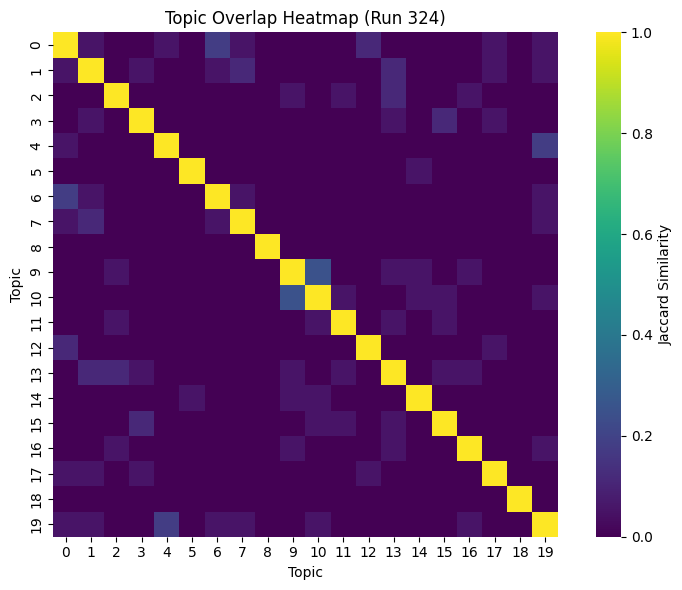

In [16]:
# heatmap for one run (Within-Run Topic Overlap)  
run_index = SEEDS.index(324)

topic_sets = top_words_runs[run_index]

# compute Jaccard similarity matrix
jaccard_matrix = np.zeros((K, K))
for i in range(K):
    for j in range(K):
        if i != j:
            inter = len(topic_sets[i].intersection(topic_sets[j]))
            union = len(topic_sets[i].union(topic_sets[j]))
            jaccard_matrix[i, j] = inter / union
        else:
            jaccard_matrix[i, j] = 1.0  # Diagonal = 1


plt.figure(figsize=(8, 6))
sns.heatmap(jaccard_matrix, cmap="viridis", square=True, cbar_kws={"label": "Jaccard Similarity"})
plt.title(f"Topic Overlap Heatmap (Run {SEEDS[run_index]})")
plt.xlabel("Topic")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

In [17]:
from gensim.models import LdaModel

lda_model_final = LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics= K,
    random_state=324,
    iterations=100,
    passes=10,
    alpha='symmetric',
    eta='symmetric',
    eval_every=None
)


In [103]:

TOP_N_WORDS = 15

for topic_id in range(lda_model_final.num_topics):
    top_words = [word for word, _ in lda_model_final.show_topic(topic_id, topn=TOP_N_WORDS)]
    print(f"Topic {topic_id}: {', '.join(top_words)}")

Topic 0: white, black, race, racist, culture, racism, minority, group, person, problem, different, issue, privilege, asian, live
Topic 1: human, animal, life, eat, kill, live, food, fat, moral, person, meat, death, suffering, dog, morality
Topic 2: time, car, sport, play, game, alcohol, movie, team, world, music, year, drive, enjoy, win, pretty
Topic 3: gun, kill, shoot, weapon, law, firearm, ban, police, state, murder, gun_control, time, death, crime, criminal
Topic 4: woman, man, rape, feminist, sex, consent, feminism, issue, victim, problem, happen, crime, likely, person, society
Topic 5: protest, drug, student, college, university, school, campus, scholarship, platform, libertarian, government, drunk_driving, smart, prison, college_student
Topic 6: word, person, racist, definition, racism, joke, offend, crime, insult, asshole, law, context, offensive, define, punishment
Topic 7: child, kid, parent, life, abortion, choice, person, family, risk, baby, adult, sex, decision, mother, ti

In [89]:
from collections import defaultdict

# === Settings ===
TOPIC_IDS = [3, 7, 9]
TOP_N_DOCS = 12

# === Compute topic distributions ===
topic_dists = lda_model_final.get_document_topics(corpus_bow, minimum_probability=0.0)

# === Collect and print top documents ===
top_docs = defaultdict(list)

for doc_id, topic_probs in enumerate(topic_dists):
    for tid, prob in topic_probs:
        if tid in TOPIC_IDS:
            top_docs[tid].append((doc_id, prob))

for tid in TOPIC_IDS:
    sorted_docs = sorted(top_docs[tid], key=lambda x: x[1], reverse=True)[:TOP_N_DOCS]
    print(f"\nTop {TOP_N_DOCS} documents for Topic {tid}:")
    for doc_id, prob in sorted_docs:
        doc_num = df_corpus.loc[doc_id, "doc_num"]
        print(f"Doc_Num {doc_num:>6} | Prob = {prob:6.3f}")



Top 12 documents for Topic 3:
Doc_Num    203 | Prob =  0.858
Doc_Num   6434 | Prob =  0.824
Doc_Num    204 | Prob =  0.794
Doc_Num   3127 | Prob =  0.732
Doc_Num   3619 | Prob =  0.719
Doc_Num   6099 | Prob =  0.704
Doc_Num   4375 | Prob =  0.695
Doc_Num   2287 | Prob =  0.694
Doc_Num   2829 | Prob =  0.685
Doc_Num   2274 | Prob =  0.679
Doc_Num   3620 | Prob =  0.677
Doc_Num    237 | Prob =  0.676

Top 12 documents for Topic 7:
Doc_Num   4852 | Prob =  0.987
Doc_Num   6824 | Prob =  0.941
Doc_Num   2891 | Prob =  0.940
Doc_Num   3960 | Prob =  0.937
Doc_Num   2314 | Prob =  0.914
Doc_Num   4732 | Prob =  0.894
Doc_Num   1064 | Prob =  0.891
Doc_Num   3222 | Prob =  0.889
Doc_Num   1051 | Prob =  0.876
Doc_Num   5100 | Prob =  0.867
Doc_Num   4066 | Prob =  0.852
Doc_Num   5818 | Prob =  0.846

Top 12 documents for Topic 9:
Doc_Num   4179 | Prob =  0.980
Doc_Num   6327 | Prob =  0.916
Doc_Num    374 | Prob =  0.902
Doc_Num   6540 | Prob =  0.901
Doc_Num   6544 | Prob =  0.815
Doc_Num 

In [90]:
# === Settings ===
TOPIC_ID_BORDERLINE = 9
TOP_N_BORDERLINE = 3
BORDERLINE_RANGE = (0.10, 0.25)

# === Collect and print borderline documents for Topic 9 ===
borderline_docs = []

for doc_id, topic_probs in enumerate(topic_dists):
    topic_dict = dict(topic_probs)
    prob = topic_dict.get(TOPIC_ID_BORDERLINE, 0)
    if BORDERLINE_RANGE[0] <= prob <= BORDERLINE_RANGE[1]:
        borderline_docs.append((doc_id, prob))

borderline_docs = sorted(borderline_docs, key=lambda x: x[1], reverse=True)[:TOP_N_BORDERLINE]

print(f"\nTop {TOP_N_BORDERLINE} borderline documents for Topic {TOPIC_ID_BORDERLINE}:")
for doc_id, prob in borderline_docs:
    doc_num = df_corpus.loc[doc_id, "doc_num"]
    print(f"Doc_Num {doc_num:>6} | Prob = {prob:6.3f}")



Top 3 borderline documents for Topic 9:
Doc_Num    152 | Prob =  0.250
Doc_Num   2861 | Prob =  0.249
Doc_Num   4900 | Prob =  0.248


In [93]:
from collections import defaultdict
import pandas as pd

# === Settings ===
TOPIC_IDS = [3, 7, 9]
TOP_N_DOCS = 12
TOPIC_ID_BORDERLINE = 9
TOP_N_BORDERLINE = 3
BORDERLINE_RANGE = (0.10, 0.25)

# === Step 1: Compute topic distributions ===
topic_dists = lda_model_final.get_document_topics(corpus_bow, minimum_probability=0.0)

# === Step 2: Collect top and borderline documents ===
top_docs_all = defaultdict(list)
borderline_docs = []

for doc_id, topic_probs in enumerate(topic_dists):
    topic_dict = dict(topic_probs)
    
    # Collect top documents for each selected topic
    for tid in TOPIC_IDS:
        prob = topic_dict.get(tid, 0)
        if prob > 0:
            top_docs_all[tid].append((doc_id, prob))
    
    # Collect borderline documents for Topic 9
    prob_9 = topic_dict.get(TOPIC_ID_BORDERLINE, 0)
    if BORDERLINE_RANGE[0] <= prob_9 <= BORDERLINE_RANGE[1]:
        borderline_docs.append((doc_id, prob_9))

# === Step 3: Build records ===
records_top = []

# Top documents (Topics 3, 7, 9)
for tid in TOPIC_IDS:
    top_docs = sorted(top_docs_all[tid], key=lambda x: x[1], reverse=True)[:TOP_N_DOCS]
    for doc_id, prob in top_docs:
        row = df_corpus.loc[doc_id]
        records_top.append({
            "Topic": tid,
            "Doc_Num": row["doc_num"],
            "Prob_Topic": round(prob, 4),
            "Type": "Top",
            "Original_Text": row["original_unescaped"]
        })

# Borderline documents (Topic 9) — store separately for appending later
records_borderline = []
borderline_docs = sorted(borderline_docs, key=lambda x: x[1], reverse=True)[:TOP_N_BORDERLINE]
for doc_id, prob in borderline_docs:
    row = df_corpus.loc[doc_id]
    records_borderline.append({
        "Topic": TOPIC_ID_BORDERLINE,
        "Doc_Num": row["doc_num"],
        "Prob_Topic": round(prob, 4),
        "Type": "Borderline",
        "Original_Text": row["original_unescaped"]
    })

# === Step 4: Combine and export ===
# Top docs first, borderline docs appended at the end
all_records = records_top + records_borderline
df_rta = pd.DataFrame(all_records)

df_rta.to_csv("rta_topic_docs.csv", index=False, encoding="utf-8")
 